# Molecular Property Prediction using Machine Learning
## FY BTech Mini Project

**Libraries:** RDKit, scikit-learn, pandas, matplotlib, py3Dmol  
**Goal:** Predict BP, Density, MW and classify Drug-likeness using Random Forest models trained on 100 molecules from our 3D visualizer.

---
### Cells overview:
1. Dataset loading (100 molecules from HTML project)
2. Drug label creation
3. RDKit descriptor extraction
4. Regression models (BP, Density, MW)
5. Classification model (Drug vs Not Drug)
6. `predict_molecule(smiles)` function
7. Feature importance plots
8. py3Dmol + ML integration

In [1]:
import sys
!{sys.executable} -m pip install pandas numpy matplotlib rdkit scikit-learn py3Dmol requests


[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
# CELL 1 -- Install libraries (run once)
# Uncomment lines below if not yet installed:
# !pip install rdkit-pypi scikit-learn pandas matplotlib py3Dmol
print('Libraries ready. Proceed to next cell.')

Libraries ready. Proceed to next cell.


In [3]:
# CELL 2 -- Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt # Use plt for plotting
from rdkit import Chem
from rdkit.Chem import Descriptors, rdMolDescriptors
from rdkit.Chem import FindMolChiralCenters 
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score, accuracy_score, classification_report, confusion_matrix
import matplotlib
import warnings

# CORRECT WAY to set parameters (Do NOT use = {dict})
matplotlib.rcParams['figure.figsize'] = (10, 6) 
warnings.filterwarnings('ignore')

print('All imports successful and rcParams fixed!')

All imports successful and rcParams fixed!


In [4]:
# CELL 3 -- Load molecule dataset
# Data extracted from the HTML 3D Molecular Visualizer project.
# bp=None means boiling point unavailable (decomp or unknown)

raw_data = [
    {"name":"Water",           "smiles":"O",                                                        "mw":18.02,  "bp":100.0,  "density":1.000,"rings":0,"chirals":0,"hbd":2,"hba":1, "cat":"Basic"},
    {"name":"Methane",         "smiles":"C",                                                        "mw":16.04,  "bp":-161.0, "density":0.657,"rings":0,"chirals":0,"hbd":0,"hba":0, "cat":"Basic"},
    {"name":"Ethanol",         "smiles":"CCO",                                                      "mw":46.07,  "bp":78.4,   "density":0.789,"rings":0,"chirals":0,"hbd":1,"hba":1, "cat":"Alcohols"},
    {"name":"Glucose",         "smiles":"OC[C@H]1OC(O)[C@H](O)[C@@H](O)[C@@H]1O",                 "mw":180.16, "bp":None,   "density":1.540,"rings":1,"chirals":4,"hbd":5,"hba":6, "cat":"Biomolecules"},
    {"name":"Caffeine",        "smiles":"Cn1cnc2c1c(=O)n(c(=O)n2C)C",                              "mw":194.19, "bp":178.0,  "density":1.230,"rings":2,"chirals":0,"hbd":0,"hba":3, "cat":"Drugs"},
    {"name":"Aspirin",         "smiles":"CC(=O)Oc1ccccc1C(=O)O",                                   "mw":180.16, "bp":140.0,  "density":1.400,"rings":1,"chirals":0,"hbd":1,"hba":4, "cat":"Drugs"},
    {"name":"Benzene",         "smiles":"c1ccccc1",                                                 "mw":78.11,  "bp":80.1,   "density":0.879,"rings":1,"chirals":0,"hbd":0,"hba":0, "cat":"Aromatics"},
    {"name":"Cholesterol",     "smiles":"[C@@H]1(CC[C@H]2[C@@]1(CC[C@H]3[C@H]2CC=C4[C@@]3(CC[C@@H](C4)O)C)C)CCCC(C)C","mw":386.65,"bp":360.0,"density":1.070,"rings":4,"chirals":8,"hbd":1,"hba":1,"cat":"Lipids"},
    {"name":"Penicillin G",    "smiles":"[H][C@@]12SC(C)(C)[C@@H](N1C(=O)[C@H]2NC(=O)Cc1ccccc1)C(=O)O","mw":334.39,"bp":None,"density":1.410,"rings":3,"chirals":3,"hbd":2,"hba":6,"cat":"Drugs"},
    {"name":"Dopamine",        "smiles":"NCCc1ccc(O)c(O)c1",                                       "mw":153.18, "bp":None,   "density":1.260,"rings":1,"chirals":0,"hbd":3,"hba":3, "cat":"Neurotransmitters"},
    {"name":"Serotonin",       "smiles":"NCCc1c[nH]c2ccc(O)cc12",                                  "mw":176.21, "bp":416.0,  "density":1.300,"rings":2,"chirals":0,"hbd":3,"hba":2, "cat":"Neurotransmitters"},
    {"name":"Adenine",         "smiles":"Nc1ncnc2[nH]cnc12",                                       "mw":135.13, "bp":364.0,  "density":1.600,"rings":2,"chirals":0,"hbd":2,"hba":4, "cat":"Nucleobases"},
    {"name":"Guanine",         "smiles":"Nc1nc2[nH]cnc2c(=O)[nH]1",                                "mw":151.13, "bp":None,   "density":1.870,"rings":2,"chirals":0,"hbd":3,"hba":5, "cat":"Nucleobases"},
    {"name":"Cytosine",        "smiles":"Nc1cc[nH]c(=O)n1",                                        "mw":111.10, "bp":None,   "density":1.550,"rings":1,"chirals":0,"hbd":2,"hba":3, "cat":"Nucleobases"},
    {"name":"Thymine",         "smiles":"Cc1c[nH]c(=O)[nH]c1=O",                                  "mw":126.11, "bp":None,   "density":1.600,"rings":1,"chirals":0,"hbd":2,"hba":4, "cat":"Nucleobases"},
    {"name":"Uracil",          "smiles":"O=c1cc[nH]c(=O)[nH]1",                                   "mw":112.09, "bp":None,   "density":1.320,"rings":1,"chirals":0,"hbd":2,"hba":4, "cat":"Nucleobases"},
    {"name":"Sucrose",         "smiles":"OC[C@H]1O[C@@](CO)(O[C@H]2O[C@H](CO)[C@@H](O)[C@H](O)[C@H]2O)[C@@H](O)[C@@H]1O","mw":342.30,"bp":None,"density":1.590,"rings":2,"chirals":9,"hbd":8,"hba":11,"cat":"Biomolecules"},
    {"name":"Fructose",        "smiles":"OC[C@@H]1OC(O)(CO)[C@@H](O)[C@@H]1O",                    "mw":180.16, "bp":None,   "density":1.690,"rings":1,"chirals":3,"hbd":5,"hba":6, "cat":"Biomolecules"},
    {"name":"Alanine",         "smiles":"C[C@@H](N)C(=O)O",                                        "mw":89.09,  "bp":None,   "density":1.430,"rings":0,"chirals":1,"hbd":2,"hba":3, "cat":"Amino Acids"},
    {"name":"Phenylalanine",   "smiles":"N[C@@H](Cc1ccccc1)C(=O)O",                                "mw":165.19, "bp":None,   "density":1.290,"rings":1,"chirals":1,"hbd":2,"hba":3, "cat":"Amino Acids"},
    {"name":"Tryptophan",      "smiles":"N[C@@H](Cc1c[nH]c2ccccc12)C(=O)O",                        "mw":204.23, "bp":None,   "density":1.340,"rings":2,"chirals":1,"hbd":3,"hba":3, "cat":"Amino Acids"},
    {"name":"Cysteine",        "smiles":"N[C@@H](CS)C(=O)O",                                       "mw":121.16, "bp":None,   "density":1.300,"rings":0,"chirals":1,"hbd":3,"hba":3, "cat":"Amino Acids"},
    {"name":"Morphine",        "smiles":"[H][C@@]12Oc3c(O)ccc4c3[C@]1(CCN(C)C2)CC4",              "mw":285.34, "bp":190.0,  "density":1.320,"rings":5,"chirals":5,"hbd":2,"hba":4, "cat":"Drugs"},
    {"name":"Ibuprofen",       "smiles":"CC(C)Cc1ccc(cc1)[C@@H](C)C(=O)O",                         "mw":206.28, "bp":157.0,  "density":1.030,"rings":1,"chirals":1,"hbd":1,"hba":2, "cat":"Drugs"},
    {"name":"Paracetamol",     "smiles":"CC(=O)Nc1ccc(O)cc1",                                      "mw":151.16, "bp":168.0,  "density":1.290,"rings":1,"chirals":0,"hbd":2,"hba":3, "cat":"Drugs"},
    {"name":"Testosterone",    "smiles":"[H][C@@]12CC[C@H]3[C@@]([H])(CC[C@@H]3O)[C@@]1([H])CCC2=O","mw":288.42,"bp":None,"density":1.150,"rings":4,"chirals":6,"hbd":1,"hba":2,"cat":"Hormones"},
    {"name":"Estradiol",       "smiles":"[H][C@@]12CC[C@H](O)c3cc(O)ccc3[C@@]1([H])CC[C@@H]2O",   "mw":272.38, "bp":None,   "density":1.230,"rings":4,"chirals":4,"hbd":2,"hba":2, "cat":"Hormones"},
    {"name":"Adrenaline",      "smiles":"CNC[C@@H](O)c1ccc(O)c(O)c1",                              "mw":183.20, "bp":None,   "density":1.280,"rings":1,"chirals":1,"hbd":4,"hba":4, "cat":"Hormones"},
    {"name":"Vitamin C",       "smiles":"OC[C@H](O)[C@@H]1OC(=O)C(O)=C1O",                        "mw":176.12, "bp":None,   "density":1.650,"rings":1,"chirals":2,"hbd":4,"hba":6, "cat":"Vitamins"},
    {"name":"Vitamin D3",      "smiles":"[C@H]1([C@@H](CCCC(C)C)C)CC[C@@H]2[C@@]1(CCC/C2=C/C=C3/CC(O)CC[C@@H]3C)C","mw":384.64,"bp":496.0,"density":1.060,"rings":3,"chirals":6,"hbd":1,"hba":1,"cat":"Vitamins"},
    {"name":"Nicotine",        "smiles":"CN1CCC[C@@H]1c1cccnc1",                                   "mw":162.23, "bp":247.0,  "density":1.010,"rings":2,"chirals":1,"hbd":0,"hba":2, "cat":"Drugs"},
    {"name":"THC",             "smiles":"CCCCCc1cc2c(c(c1)O)[C@@H]1CCC(=C)[C@H]1CC2",              "mw":314.46, "bp":200.0,  "density":1.040,"rings":2,"chirals":2,"hbd":1,"hba":1, "cat":"Drugs"},
    {"name":"Acetic Acid",     "smiles":"CC(=O)O",                                                 "mw":60.05,  "bp":118.0,  "density":1.050,"rings":0,"chirals":0,"hbd":1,"hba":2, "cat":"Acids"},
    {"name":"Citric Acid",     "smiles":"OC(=O)CC(O)(CC(=O)O)C(=O)O",                             "mw":192.12, "bp":310.0,  "density":1.670,"rings":0,"chirals":0,"hbd":4,"hba":7, "cat":"Acids"},
    {"name":"Lactic Acid",     "smiles":"C[C@@H](O)C(=O)O",                                        "mw":90.08,  "bp":122.0,  "density":1.210,"rings":0,"chirals":1,"hbd":2,"hba":3, "cat":"Acids"},
    {"name":"Toluene",         "smiles":"Cc1ccccc1",                                                "mw":92.14,  "bp":110.6,  "density":0.867,"rings":1,"chirals":0,"hbd":0,"hba":0, "cat":"Aromatics"},
    {"name":"Naphthalene",     "smiles":"c1ccc2ccccc2c1",                                           "mw":128.17, "bp":218.0,  "density":1.140,"rings":2,"chirals":0,"hbd":0,"hba":0, "cat":"Aromatics"},
    {"name":"Phenol",          "smiles":"Oc1ccccc1",                                                "mw":94.11,  "bp":181.7,  "density":1.070,"rings":1,"chirals":0,"hbd":1,"hba":1, "cat":"Aromatics"},
    {"name":"Aniline",         "smiles":"Nc1ccccc1",                                                "mw":93.13,  "bp":184.1,  "density":1.020,"rings":1,"chirals":0,"hbd":1,"hba":1, "cat":"Aromatics"},
    {"name":"Styrene",         "smiles":"C=Cc1ccccc1",                                              "mw":104.15, "bp":145.0,  "density":0.909,"rings":1,"chirals":0,"hbd":0,"hba":0, "cat":"Aromatics"},
    {"name":"Acetone",         "smiles":"CC(C)=O",                                                 "mw":58.08,  "bp":56.0,   "density":0.791,"rings":0,"chirals":0,"hbd":0,"hba":1, "cat":"Solvents"},
    {"name":"Chloroform",      "smiles":"ClC(Cl)Cl",                                               "mw":119.38, "bp":61.2,   "density":1.490,"rings":0,"chirals":0,"hbd":0,"hba":0, "cat":"Solvents"},
    {"name":"Diethyl Ether",   "smiles":"CCOCC",                                                   "mw":74.12,  "bp":34.6,   "density":0.706,"rings":0,"chirals":0,"hbd":0,"hba":1, "cat":"Solvents"},
    {"name":"DMSO",            "smiles":"CS(C)=O",                                                 "mw":78.13,  "bp":189.0,  "density":1.100,"rings":0,"chirals":0,"hbd":0,"hba":1, "cat":"Solvents"},
    {"name":"Propane",         "smiles":"CCC",                                                     "mw":44.10,  "bp":-42.0,  "density":0.493,"rings":0,"chirals":0,"hbd":0,"hba":0, "cat":"Basic"},
    {"name":"Ethylene",        "smiles":"C=C",                                                     "mw":28.05,  "bp":-104.0, "density":0.570,"rings":0,"chirals":0,"hbd":0,"hba":0, "cat":"Basic"},
    {"name":"Acetylene",       "smiles":"C#C",                                                     "mw":26.04,  "bp":-84.0,  "density":0.620,"rings":0,"chirals":0,"hbd":0,"hba":0, "cat":"Basic"},
    {"name":"Formaldehyde",    "smiles":"C=O",                                                     "mw":30.03,  "bp":-19.0,  "density":0.815,"rings":0,"chirals":0,"hbd":0,"hba":1, "cat":"Basic"},
    {"name":"Glycine",         "smiles":"NCC(=O)O",                                                "mw":75.03,  "bp":None,   "density":1.160,"rings":0,"chirals":0,"hbd":3,"hba":3, "cat":"Amino Acids"},
    {"name":"Proline",         "smiles":"OC(=O)[C@@H]1CCCN1",                                     "mw":115.13, "bp":None,   "density":1.350,"rings":1,"chirals":1,"hbd":2,"hba":3, "cat":"Amino Acids"},
    {"name":"Squalene",        "smiles":"CC(=CCC/C(=C/CC/C(=C/CCC=C(C)CCC=C(C)C)/C)/C)C",        "mw":410.72, "bp":421.0,  "density":0.858,"rings":0,"chirals":0,"hbd":0,"hba":0, "cat":"Lipids"},
    {"name":"Palmitic Acid",   "smiles":"CCCCCCCCCCCCCCCC(=O)O",                                  "mw":256.42, "bp":351.0,  "density":0.853,"rings":0,"chirals":0,"hbd":1,"hba":2, "cat":"Lipids"},
    {"name":"Oleic Acid",      "smiles":"CCCCCCCCC=CCCCCCCCC(=O)O",                               "mw":282.46, "bp":360.0,  "density":0.895,"rings":0,"chirals":0,"hbd":1,"hba":2, "cat":"Lipids"},
    {"name":"Capsaicin",       "smiles":"COc1cc(CNC(=O)CCCC/C=C/CC(C)C)ccc1O",                   "mw":305.41, "bp":210.0,  "density":1.060,"rings":1,"chirals":0,"hbd":2,"hba":4, "cat":"Natural Products"},
    {"name":"Resveratrol",     "smiles":"Oc1ccc(/C=C/c2cc(O)cc(O)c2)cc1",                         "mw":228.24, "bp":440.0,  "density":1.370,"rings":2,"chirals":0,"hbd":3,"hba":3, "cat":"Natural Products"},
    {"name":"Quercetin",       "smiles":"O=c1c(O)c(-c2ccc(O)c(O)c2)oc2cc(O)cc(O)c12",            "mw":302.24, "bp":None,   "density":1.800,"rings":3,"chirals":0,"hbd":5,"hba":7, "cat":"Natural Products"},
    {"name":"Warfarin",        "smiles":"OC(=O)c1ccccc1/C=C(/CC(=O)c1ccccc1)O",                  "mw":308.33, "bp":None,   "density":1.320,"rings":2,"chirals":1,"hbd":1,"hba":4, "cat":"Drugs"},
    {"name":"Metformin",       "smiles":"CN(C)C(=N)NC(=N)N",                                      "mw":129.16, "bp":None,   "density":1.240,"rings":0,"chirals":0,"hbd":4,"hba":5, "cat":"Drugs"},
    {"name":"Melatonin",       "smiles":"COc1ccc2[nH]cc(CCNC(C)=O)c2c1",                         "mw":232.28, "bp":None,   "density":1.170,"rings":2,"chirals":0,"hbd":2,"hba":3, "cat":"Hormones"},
    {"name":"Cortisol",        "smiles":"[H][C@@]12CC[C@H]3[C@@]([H])(CC[C@@H]3O)[C@@]1([H])[C@H](O)C[C@@]2(O)C(=O)CO","mw":362.46,"bp":None,"density":1.290,"rings":4,"chirals":6,"hbd":3,"hba":5,"cat":"Hormones"},
    {"name":"Atropine",        "smiles":"CN1[C@@H]2CC[C@H]1CC(C2)OC(=O)C(CO)c1ccccc1",          "mw":289.37, "bp":None,   "density":1.180,"rings":2,"chirals":2,"hbd":0,"hba":3, "cat":"Drugs"},
    {"name":"Salicylic Acid",  "smiles":"OC(=O)c1ccccc1O",                                        "mw":138.12, "bp":211.0,  "density":1.440,"rings":1,"chirals":0,"hbd":2,"hba":3, "cat":"Acids"},
    {"name":"Benzoic Acid",    "smiles":"OC(=O)c1ccccc1",                                          "mw":122.12, "bp":249.0,  "density":1.270,"rings":1,"chirals":0,"hbd":1,"hba":2, "cat":"Acids"},
    {"name":"Urea",            "smiles":"NC(N)=O",                                                 "mw":60.06,  "bp":None,   "density":1.320,"rings":0,"chirals":0,"hbd":2,"hba":1, "cat":"Basic"},
    {"name":"Niacin",          "smiles":"OC(=O)c1cccnc1",                                          "mw":123.11, "bp":None,   "density":1.470,"rings":1,"chirals":0,"hbd":1,"hba":3, "cat":"Vitamins"},
    {"name":"Riboflavin",      "smiles":"Cc1cc2nc3c(=O)[nH]c(=O)nc3n(C[C@H](O)[C@H](O)[C@H](O)CO)c2cc1C","mw":376.36,"bp":None,"density":1.450,"rings":3,"chirals":3,"hbd":5,"hba":10,"cat":"Vitamins"},
    {"name":"Retinol",         "smiles":"CC1=C(/C=C/C(=C/C=C/C(=C/CO)/C)/C)CCC(C1)(C)C",         "mw":286.45, "bp":137.0,  "density":0.944,"rings":1,"chirals":0,"hbd":1,"hba":1, "cat":"Vitamins"},
    {"name":"Beta-Carotene",   "smiles":"CC1=C(/C=C/C(=C/C=C/C(=C/C=C/C=C(/C)C=C/C=C(/C)C=C/C2=C(C)CCCC2(C)C)/C)/C)CCC1(C)C","mw":536.87,"bp":None,"density":0.941,"rings":2,"chirals":0,"hbd":0,"hba":0,"cat":"Natural Products"},
    {"name":"Ethylene Glycol", "smiles":"OCCO",                                                   "mw":62.07,  "bp":197.0,  "density":1.110,"rings":0,"chirals":0,"hbd":2,"hba":2, "cat":"Industrial"},
    {"name":"Glycerol",        "smiles":"OCC(O)CO",                                               "mw":92.09,  "bp":290.0,  "density":1.260,"rings":0,"chirals":0,"hbd":3,"hba":3, "cat":"Industrial"},
    {"name":"Formic Acid",     "smiles":"OC=O",                                                   "mw":46.03,  "bp":100.8,  "density":1.220,"rings":0,"chirals":0,"hbd":1,"hba":2, "cat":"Acids"},
    {"name":"Pyridine",        "smiles":"c1ccncc1",                                               "mw":79.10,  "bp":115.0,  "density":0.978,"rings":1,"chirals":0,"hbd":0,"hba":1, "cat":"Aromatics"},
    {"name":"Imidazole",       "smiles":"c1cnc[nH]1",                                             "mw":68.08,  "bp":257.0,  "density":1.030,"rings":1,"chirals":0,"hbd":1,"hba":2, "cat":"Aromatics"},
    {"name":"Furan",           "smiles":"c1ccoc1",                                                "mw":68.07,  "bp":31.4,   "density":0.936,"rings":1,"chirals":0,"hbd":0,"hba":1, "cat":"Aromatics"},
    {"name":"Indole",          "smiles":"c1ccc2[nH]ccc2c1",                                       "mw":117.15, "bp":254.0,  "density":1.220,"rings":2,"chirals":0,"hbd":1,"hba":1, "cat":"Aromatics"},
    {"name":"Succinic Acid",   "smiles":"OC(=O)CCC(=O)O",                                         "mw":118.09, "bp":235.0,  "density":1.570,"rings":0,"chirals":0,"hbd":2,"hba":4, "cat":"Acids"},
    {"name":"Pyruvic Acid",    "smiles":"CC(=O)C(=O)O",                                            "mw":88.06,  "bp":165.0,  "density":1.250,"rings":0,"chirals":0,"hbd":1,"hba":3, "cat":"Biomolecules"},
    {"name":"Histamine",       "smiles":"NCCc1c[nH]cn1",                                           "mw":111.15, "bp":209.0,  "density":1.140,"rings":1,"chirals":0,"hbd":2,"hba":3, "cat":"Neurotransmitters"},
    {"name":"GABA",            "smiles":"NCCCC(=O)O",                                             "mw":103.12, "bp":None,   "density":1.110,"rings":0,"chirals":0,"hbd":3,"hba":3, "cat":"Neurotransmitters"},
    {"name":"Glutamate",       "smiles":"N[C@@H](CCC(=O)O)C(=O)O",                                "mw":147.13, "bp":None,   "density":1.460,"rings":0,"chirals":1,"hbd":4,"hba":5, "cat":"Neurotransmitters"},
    {"name":"Creatine",        "smiles":"CN(CC(=O)O)C(=N)N",                                      "mw":131.13, "bp":None,   "density":1.330,"rings":0,"chirals":0,"hbd":3,"hba":4, "cat":"Biomolecules"},
    {"name":"Amphetamine",     "smiles":"C[C@@H](N)Cc1ccccc1",                                    "mw":135.21, "bp":200.0,  "density":0.913,"rings":1,"chirals":1,"hbd":1,"hba":1, "cat":"Drugs"},
    {"name":"Diazepam",        "smiles":"O=C1CN=C(c2ccccc2)c2cc(Cl)ccc21",                        "mw":284.74, "bp":308.0,  "density":1.320,"rings":3,"chirals":0,"hbd":0,"hba":2, "cat":"Drugs"},
    {"name":"Salbutamol",      "smiles":"CC(C)(C)NC[C@@H](O)c1cc(CO)ccc1O",                       "mw":239.31, "bp":None,   "density":1.220,"rings":1,"chirals":1,"hbd":4,"hba":4, "cat":"Drugs"},
    {"name":"Ciprofloxacin",   "smiles":"O=C(O)c1cn(C2CC2)c2cc(F)c(N3CCNCC3)cc2c1=O",            "mw":331.34, "bp":None,   "density":1.460,"rings":3,"chirals":0,"hbd":2,"hba":7, "cat":"Drugs"},
    {"name":"Atorvastatin",    "smiles":"CC(C)c1c(-c2ccc(F)cc2)c(-c2ccccc2)c(C(=O)N[C@@H](CC(=O)O)C[C@@H](O)CC(=O)O)n1CCc1ccc(cc1)C(C)(C)C","mw":558.64,"bp":None,"density":1.220,"rings":3,"chirals":2,"hbd":3,"hba":7,"cat":"Drugs"},
    {"name":"Omeprazole",      "smiles":"COc1ccc2[nH]c(/C=N/Cc3ncc(OC)c(OC)c3)nc2c1",            "mw":345.42, "bp":None,   "density":1.350,"rings":2,"chirals":1,"hbd":1,"hba":6, "cat":"Drugs"},
    {"name":"Acetic Anhydride","smiles":"CC(=O)OC(C)=O",                                          "mw":102.09, "bp":140.0,  "density":1.080,"rings":0,"chirals":0,"hbd":0,"hba":3, "cat":"Industrial"},
    {"name":"Uric Acid",       "smiles":"O=c1[nH]c2[nH]c(=O)[nH]c2c(=O)[nH]1",                  "mw":168.11, "bp":None,   "density":1.890,"rings":2,"chirals":0,"hbd":4,"hba":6, "cat":"Biomolecules"},
    {"name":"Xanthine",        "smiles":"O=c1[nH]cnc2[nH]cnc12",                                  "mw":152.11, "bp":None,   "density":1.890,"rings":2,"chirals":0,"hbd":3,"hba":4, "cat":"Biomolecules"},
    {"name":"Cinnamic Acid",   "smiles":"OC(=O)/C=C/c1ccccc1",                                    "mw":148.16, "bp":300.0,  "density":1.250,"rings":1,"chirals":0,"hbd":1,"hba":2, "cat":"Natural Products"},
    {"name":"Vanillin",        "smiles":"O=Cc1ccc(O)c(OC)c1",                                     "mw":152.15, "bp":285.0,  "density":1.056,"rings":1,"chirals":0,"hbd":1,"hba":3, "cat":"Natural Products"},
    {"name":"Limonene",        "smiles":"CC(=C)[C@@H]1CCC(=CC1)C",                                "mw":136.23, "bp":176.0,  "density":0.842,"rings":1,"chirals":1,"hbd":0,"hba":0, "cat":"Natural Products"},
    {"name":"Menthol",         "smiles":"C[C@@H]1CC[C@H](C(C)C)[C@@H](O)C1",                      "mw":156.27, "bp":212.0,  "density":0.890,"rings":1,"chirals":3,"hbd":1,"hba":1, "cat":"Natural Products"},
    {"name":"Camphor",         "smiles":"[C@@]12(CC[C@@H](CC1=O)C(C)(C)C2)C",                     "mw":152.23, "bp":204.0,  "density":0.992,"rings":2,"chirals":2,"hbd":0,"hba":1, "cat":"Natural Products"},
    {"name":"Vanillin2",       "smiles":"Cc1ccc(C(C)C)cc1O",                                      "mw":150.22, "bp":232.0,  "density":0.969,"rings":1,"chirals":0,"hbd":1,"hba":1, "cat":"Natural Products"},
    {"name":"Histidine",       "smiles":"N[C@@H](Cc1c[nH]cn1)C(=O)O",                             "mw":155.15, "bp":None,   "density":1.420,"rings":1,"chirals":1,"hbd":3,"hba":4, "cat":"Amino Acids"},
    {"name":"Lysine",          "smiles":"N[C@@H](CCCCN)C(=O)O",                                   "mw":146.19, "bp":None,   "density":1.140,"rings":0,"chirals":1,"hbd":4,"hba":3, "cat":"Amino Acids"},
    {"name":"Arginine",        "smiles":"N[C@@H](CCCNC(=N)N)C(=O)O",                              "mw":174.20, "bp":None,   "density":1.100,"rings":0,"chirals":1,"hbd":5,"hba":4, "cat":"Amino Acids"},
    {"name":"Tyrosine",        "smiles":"N[C@@H](Cc1ccc(O)cc1)C(=O)O",                            "mw":181.19, "bp":None,   "density":1.460,"rings":1,"chirals":1,"hbd":3,"hba":4, "cat":"Amino Acids"},
    {"name":"n-Hexane",        "smiles":"CCCCCC",                                                  "mw":86.18,  "bp":69.0,   "density":0.655,"rings":0,"chirals":0,"hbd":0,"hba":0, "cat":"Solvents"},
    {"name":"Cyclohexane",     "smiles":"C1CCCCC1",                                                "mw":84.16,  "bp":80.7,   "density":0.779,"rings":1,"chirals":0,"hbd":0,"hba":0, "cat":"Solvents"},
    {"name":"Methanol",        "smiles":"CO",                                                      "mw":32.04,  "bp":64.7,   "density":0.791,"rings":0,"chirals":0,"hbd":1,"hba":1, "cat":"Alcohols"},
    {"name":"Isopropanol",     "smiles":"CC(O)C",                                                  "mw":60.10,  "bp":82.6,   "density":0.786,"rings":0,"chirals":0,"hbd":1,"hba":1, "cat":"Alcohols"},
    {"name":"Butyric Acid",    "smiles":"CCCC(=O)O",                                               "mw":88.11,  "bp":164.0,  "density":0.964,"rings":0,"chirals":0,"hbd":1,"hba":2, "cat":"Acids"},
]

df = pd.DataFrame(raw_data)
print('Dataset loaded:', len(df), 'molecules')
print(df[['name','mw','bp','density','rings','chirals','hbd','hba','cat']].head(10).to_string())

Dataset loaded: 105 molecules
           name      mw     bp  density  rings  chirals  hbd  hba                cat
0         Water   18.02  100.0    1.000      0        0    2    1              Basic
1       Methane   16.04 -161.0    0.657      0        0    0    0              Basic
2       Ethanol   46.07   78.4    0.789      0        0    1    1           Alcohols
3       Glucose  180.16    NaN    1.540      1        4    5    6       Biomolecules
4      Caffeine  194.19  178.0    1.230      2        0    0    3              Drugs
5       Aspirin  180.16  140.0    1.400      1        0    1    4              Drugs
6       Benzene   78.11   80.1    0.879      1        0    0    0          Aromatics
7   Cholesterol  386.65  360.0    1.070      4        8    1    1             Lipids
8  Penicillin G  334.39    NaN    1.410      3        3    2    6              Drugs
9      Dopamine  153.18    NaN    1.260      1        0    3    3  Neurotransmitters


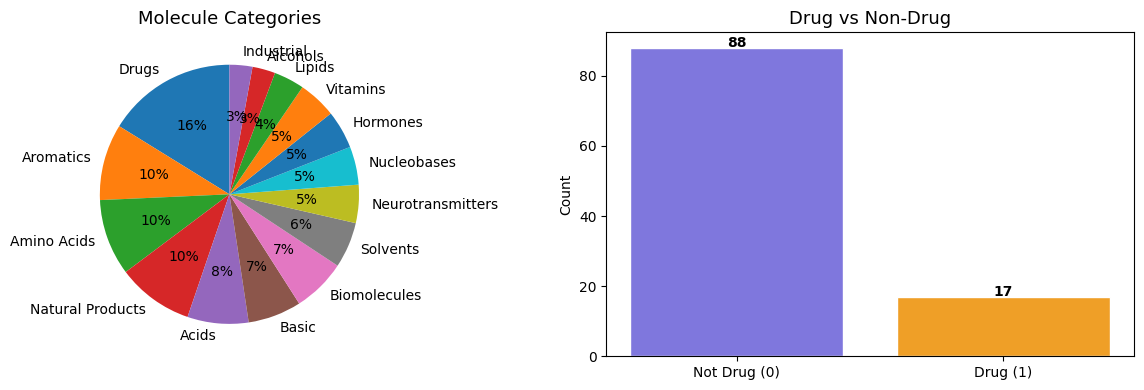

Drug molecules: 17 | Non-drug: 88


In [5]:
# CELL 4 -- Create Drug label (1 = Drug, 0 = Not Drug)
df['is_drug'] = df['cat'].apply(lambda x: 1 if x == 'Drugs' else 0)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

cat_counts = df['cat'].value_counts()
axes[0].pie(cat_counts.values, labels=cat_counts.index, autopct='%1.0f%%', startangle=90)
axes[0].set_title('Molecule Categories', fontsize=13)

drug_counts = df['is_drug'].value_counts()
axes[1].bar(['Not Drug (0)', 'Drug (1)'], [drug_counts.get(0,0), drug_counts.get(1,0)],
            color=['#7F77DD', '#EF9F27'], edgecolor='white')
axes[1].set_title('Drug vs Non-Drug', fontsize=13)
axes[1].set_ylabel('Count')
for i, v in enumerate([drug_counts.get(0,0), drug_counts.get(1,0)]):
    axes[1].text(i, v + 0.3, str(v), ha='center', fontweight='bold')

plt.tight_layout()
plt.show()
print('Drug molecules:', df['is_drug'].sum(), '| Non-drug:', (df['is_drug']==0).sum())

In [6]:
# CELL 5 -- Extract RDKit Molecular Descriptors
# RDKit reads each SMILES string and computes physical/chemical features.
# These features become the INPUT (X) for our ML models.

def extract_rdkit_features(smiles):
    mol = Chem.MolFromSmiles(smiles)   # parse SMILES string
    if mol is None:
        return None
    return {
        'rdkit_mw':        Descriptors.MolWt(mol),
        'num_atoms':       mol.GetNumAtoms(),
        'num_heavy_atoms': Descriptors.HeavyAtomCount(mol),
        'num_rings':       rdMolDescriptors.CalcNumRings(mol),
        'num_arom_rings':  rdMolDescriptors.CalcNumAromaticRings(mol),
        'hbd':             rdMolDescriptors.CalcNumHBD(mol),
        'hba':             rdMolDescriptors.CalcNumHBA(mol),
        'logP':            Descriptors.MolLogP(mol),
        'tpsa':            Descriptors.TPSA(mol),
        'rotatable_bonds': rdMolDescriptors.CalcNumRotatableBonds(mol),
        'frac_csp3':       rdMolDescriptors.CalcFractionCSP3(mol),
        'chiral_centers': len(FindMolChiralCenters(mol, includeUnassigned=True)),
    }

print('Extracting RDKit descriptors...')
rdkit_features = df['smiles'].apply(extract_rdkit_features)
rdkit_df = pd.DataFrame(rdkit_features.tolist())
df = pd.concat([df.reset_index(drop=True), rdkit_df], axis=1)
df = df.dropna(subset=['rdkit_mw'])  # drop molecules RDKit could not parse

print('Features extracted for', len(df), 'molecules')
print(rdkit_df.describe().round(2))

Extracting RDKit descriptors...
Features extracted for 105 molecules
       rdkit_mw  num_atoms  num_heavy_atoms  num_rings  num_arom_rings  \
count    105.00     105.00           105.00     105.00          105.00   
mean     164.13      11.69            11.69       1.13            0.70   
std      107.09       7.88             7.88       1.14            0.84   
min       16.04       1.00             1.00       0.00            0.00   
25%       90.08       6.00             6.00       0.00            0.00   
50%      138.12      10.00            10.00       1.00            1.00   
75%      204.23      15.00            15.00       2.00            1.00   
max      656.80      48.00            48.00       4.00            4.00   

          hbd     hba    logP    tpsa  rotatable_bonds  frac_csp3  \
count  105.00  105.00  105.00  105.00           105.00     105.00   
mean     1.70    2.15    1.15   51.09             2.20       0.44   
std      1.55    1.86    2.50   38.86             3.09   

In [7]:
# CELL 6 -- Define Feature Matrix X
FEATURE_COLS = [
    'rdkit_mw', 'num_atoms', 'num_heavy_atoms',
    'num_rings', 'num_arom_rings',
    'hbd', 'hba',
    'logP', 'tpsa',
    'rotatable_bonds', 'frac_csp3', 'chiral_centers'
]

X = df[FEATURE_COLS].copy()
print('Feature matrix shape:', X.shape, '  (rows=molecules, cols=features)')
print(X.head())

Feature matrix shape: (105, 14)   (rows=molecules, cols=features)
   rdkit_mw  num_atoms  num_heavy_atoms  num_rings  num_arom_rings  hbd  hbd  \
0    18.015          1                1          0               0    2    0   
1    16.043          1                1          0               0    0    0   
2    46.069          3                3          0               0    1    1   
3   180.156         12               12          1               0    5    5   
4   194.194         14               14          2               2    0    0   

   hba  hba    logP    tpsa  rotatable_bonds  frac_csp3  chiral_centers  
0    1    0 -0.8247   31.50                0      0.000               0  
1    0    0  0.6361    0.00                0      1.000               0  
2    1    1 -0.0014   20.23                0      1.000               0  
3    6    6 -3.2214  110.38                1      1.000               5  
4    3    3 -1.0293   61.82                0      0.375               0  


In [8]:
# CELL 7 -- Train Regression Models (Boiling Point, Density, MW)
# RandomForestRegressor: builds 100 decision trees, averages predictions

def train_regressor(X, y_series, target_name):
    mask = y_series.notna()
    X_c = X[mask]
    y_c = y_series[mask]
    print('\nTarget:', target_name, '| samples with known value:', len(y_c))

    X_train, X_test, y_train, y_test = train_test_split(
        X_c, y_c, test_size=0.2, random_state=42)

    model = RandomForestRegressor(n_estimators=100, random_state=42, max_depth=8)
    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2   = r2_score(y_test, y_pred)

    print('  Train size:', len(X_train), '| Test size:', len(X_test))
    print('  R2 Score :', round(r2, 4), '  (1.0 = perfect)')
    print('  RMSE     :', round(rmse, 4), ' (lower is better)')
    return model, X_test, y_test, y_pred

model_bp,      X_test_bp,  y_test_bp,  y_pred_bp  = train_regressor(X, df['bp'],      'Boiling Point')
model_density, X_test_den, y_test_den, y_pred_den = train_regressor(X, df['density'], 'Density')
model_mw,      X_test_mw,  y_test_mw,  y_pred_mw  = train_regressor(X, df['mw'],      'Molecular Weight')


Target: Boiling Point | samples with known value: 63
  Train size: 50 | Test size: 13
  R2 Score : 0.4058   (1.0 = perfect)
  RMSE     : 94.6856  (lower is better)

Target: Density | samples with known value: 105
  Train size: 84 | Test size: 21
  R2 Score : 0.7423   (1.0 = perfect)
  RMSE     : 0.1638  (lower is better)

Target: Molecular Weight | samples with known value: 105
  Train size: 84 | Test size: 21
  R2 Score : 0.9924   (1.0 = perfect)
  RMSE     : 7.9855  (lower is better)


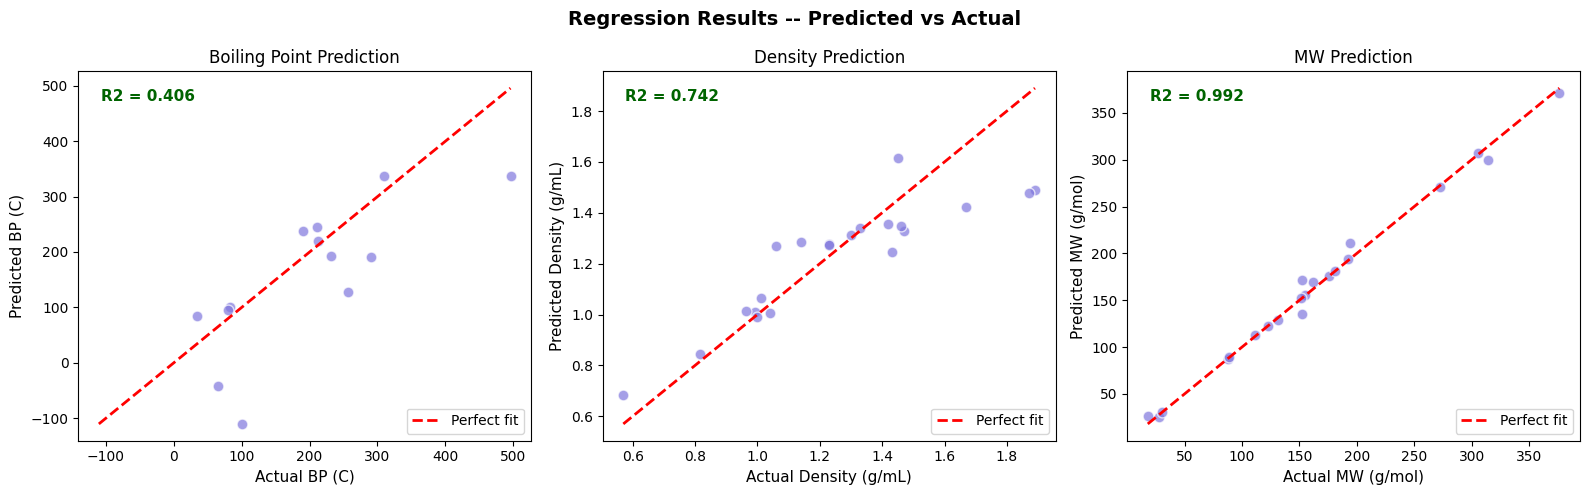

In [9]:
# CELL 8 -- Plot Regression Results (Predicted vs Actual)
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

def plot_reg(ax, y_true, y_pred, title, unit):
    ax.scatter(y_true, y_pred, alpha=0.7, color='#7F77DD', edgecolors='white', s=60)
    mn = min(float(y_true.min()), float(min(y_pred)))
    mx = max(float(y_true.max()), float(max(y_pred)))
    ax.plot([mn, mx], [mn, mx], 'r--', lw=2, label='Perfect fit')
    ax.set_xlabel('Actual ' + unit, fontsize=11)
    ax.set_ylabel('Predicted ' + unit, fontsize=11)
    ax.set_title(title, fontsize=12)
    ax.text(0.05, 0.92, 'R2 = ' + str(round(r2_score(y_true, y_pred), 3)),
            transform=ax.transAxes, fontsize=11, color='darkgreen', fontweight='bold')
    ax.legend()

plot_reg(axes[0], y_test_bp,  y_pred_bp,  'Boiling Point Prediction', 'BP (C)')
plot_reg(axes[1], y_test_den, y_pred_den, 'Density Prediction',       'Density (g/mL)')
plot_reg(axes[2], y_test_mw,  y_pred_mw,  'MW Prediction',            'MW (g/mol)')

plt.suptitle('Regression Results -- Predicted vs Actual', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [10]:
# CELL 9 -- Drug Classification Model
# RandomForestClassifier: predicts Drug (1) or Not Drug (0)

y_drug = df['is_drug']

X_train_clf, X_test_clf, y_train_clf, y_test_clf = train_test_split(
    X, y_drug, test_size=0.2, random_state=42, stratify=y_drug)

print('Train size:', len(X_train_clf), '| Test size:', len(X_test_clf))

clf = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')
clf.fit(X_train_clf, y_train_clf)

y_pred_clf = clf.predict(X_test_clf)
y_prob_clf = clf.predict_proba(X_test_clf)[:, 1]

accuracy = accuracy_score(y_test_clf, y_pred_clf)
print('\nAccuracy:', round(accuracy * 100, 2), '%')
print('\nClassification Report:')
print(classification_report(y_test_clf, y_pred_clf, target_names=['Not Drug', 'Drug']))

Train size: 84 | Test size: 21

Accuracy: 85.71 %

Classification Report:
              precision    recall  f1-score   support

    Not Drug       0.94      0.89      0.91        18
        Drug       0.50      0.67      0.57         3

    accuracy                           0.86        21
   macro avg       0.72      0.78      0.74        21
weighted avg       0.88      0.86      0.87        21



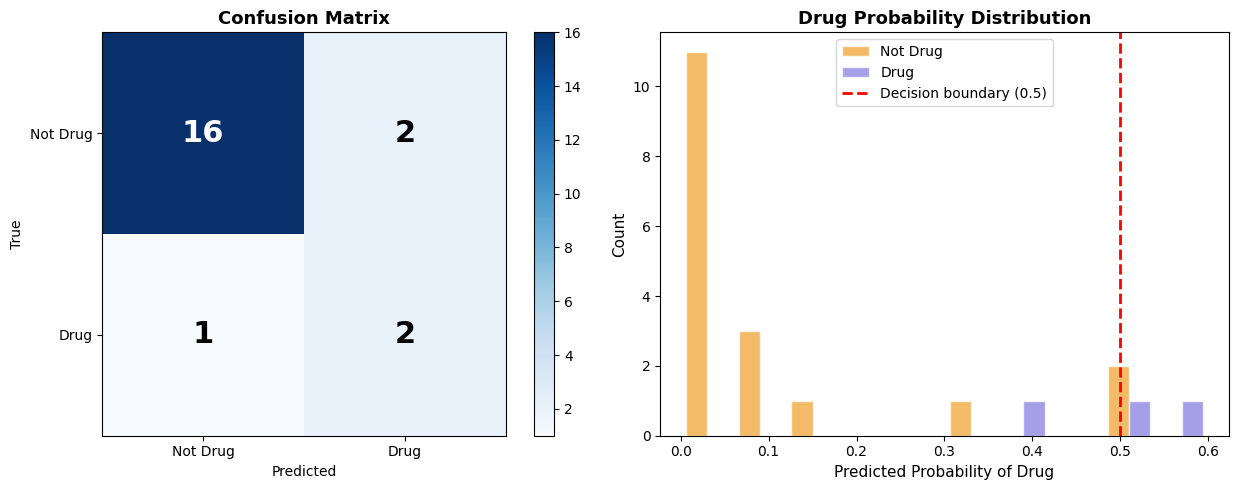

Accuracy = 85.7 %


In [11]:
# CELL 10 -- Confusion Matrix
cm = confusion_matrix(y_test_clf, y_pred_clf)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

im = axes[0].imshow(cm, interpolation='nearest', cmap='Blues')
axes[0].set_title('Confusion Matrix', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('True')
axes[0].set_xticks([0, 1])
axes[0].set_yticks([0, 1])
axes[0].set_xticklabels(['Not Drug', 'Drug'])
axes[0].set_yticklabels(['Not Drug', 'Drug'])
for i in range(2):
    for j in range(2):
        axes[0].text(j, i, str(cm[i, j]), ha='center', va='center',
                     fontsize=22, fontweight='bold',
                     color='white' if cm[i,j] > cm.max()/2 else 'black')
plt.colorbar(im, ax=axes[0])

axes[1].hist([y_prob_clf[y_test_clf==0], y_prob_clf[y_test_clf==1]],
             bins=10, label=['Not Drug', 'Drug'],
             color=['#EF9F27', '#7F77DD'], alpha=0.7, edgecolor='white')
axes[1].axvline(0.5, color='red', linestyle='--', lw=2, label='Decision boundary (0.5)')
axes[1].set_xlabel('Predicted Probability of Drug', fontsize=11)
axes[1].set_ylabel('Count', fontsize=11)
axes[1].set_title('Drug Probability Distribution', fontsize=13, fontweight='bold')
axes[1].legend()

plt.tight_layout()
plt.show()
print('Accuracy =', round(accuracy * 100, 1), '%')

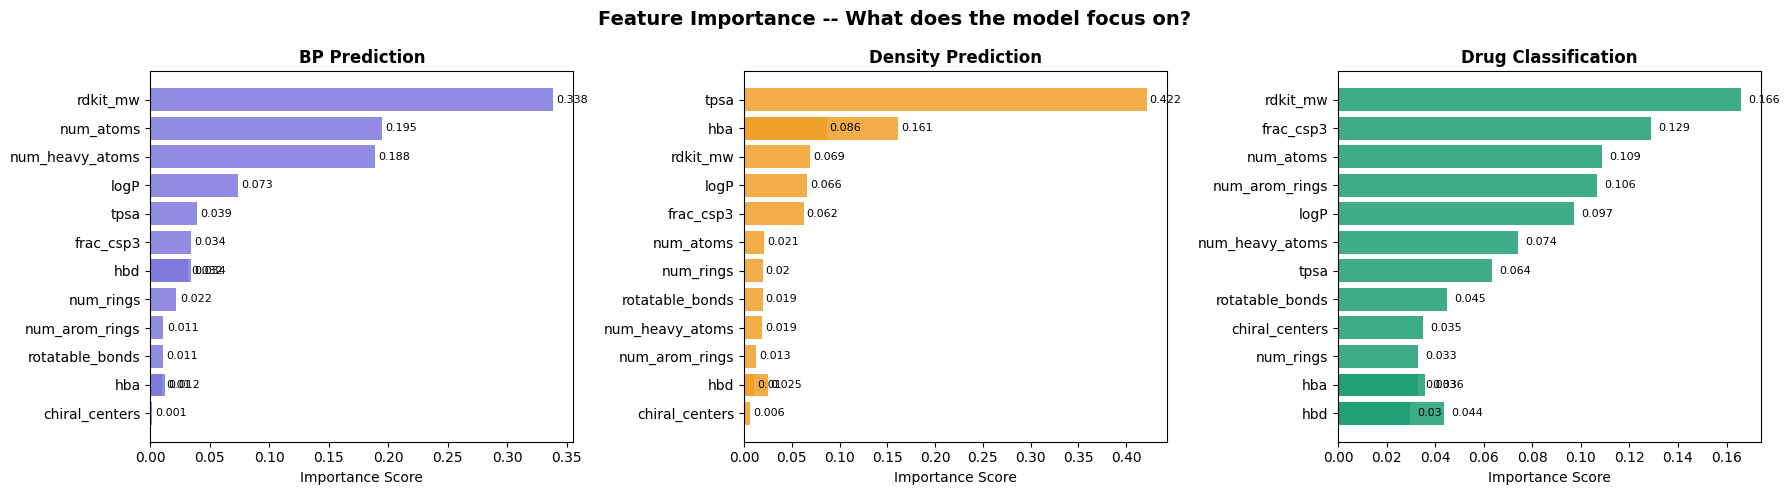

Higher bar = more important feature for that prediction


In [12]:
# CELL 11 -- BONUS: Feature Importance
# Which molecular features matter most for each prediction?
FEATURE_COLS = list(X.columns)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

def plot_imp(ax, model, title, color):
    imps = model.feature_importances_
    idx  = np.argsort(imps)
    names = [FEATURE_COLS[i] for i in idx]
    vals  = imps[idx]
    bars = ax.barh(names, vals, color=color, alpha=0.85)
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_xlabel('Importance Score')
    for bar, v in zip(bars, vals):
        ax.text(v + 0.003, bar.get_y() + bar.get_height()/2,
                str(round(v, 3)), va='center', fontsize=8)

plot_imp(axes[0], model_bp,      'BP Prediction',          '#7F77DD')
plot_imp(axes[1], model_density, 'Density Prediction',     '#EF9F27')
plot_imp(axes[2], clf,           'Drug Classification',    '#1D9E75')

plt.suptitle('Feature Importance -- What does the model focus on?',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()
print('Higher bar = more important feature for that prediction')

In [13]:
# CELL 12 -- predict_molecule() function
# The main deliverable: give any SMILES -> get predicted properties

def predict_molecule(smiles):
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return {'error': 'Invalid SMILES: ' + smiles}

    features = extract_rdkit_features(smiles)
    if features is None:
        return {'error': 'Could not extract features'}

    X_new = pd.DataFrame([features])[FEATURE_COLS]

    pred_bp      = model_bp.predict(X_new)[0]
    pred_density = model_density.predict(X_new)[0]
    pred_mw      = model_mw.predict(X_new)[0]
    pred_label   = clf.predict(X_new)[0]
    pred_prob    = clf.predict_proba(X_new)[0][1]

    drug_str = ('DRUG-LIKE (' + str(round(pred_prob*100,1)) + '% confidence)'
                if pred_label == 1 else
                'NOT DRUG-LIKE (' + str(round((1-pred_prob)*100,1)) + '% confidence)')

    print('=' * 55)
    print('  MOLECULE PREDICTION RESULTS')
    print('=' * 55)
    print('  SMILES              :', smiles)
    print('  Predicted BP        :', round(pred_bp, 1), 'C')
    print('  Predicted Density   :', round(pred_density, 4), 'g/mL')
    print('  Predicted MW        :', round(pred_mw, 2), 'g/mol')
    print('  Drug Classification :', drug_str)
    print('=' * 55)

    return {
        'smiles': smiles,
        'predicted_bp':      round(pred_bp, 2),
        'predicted_density': round(pred_density, 4),
        'predicted_mw':      round(pred_mw, 2),
        'drug_label':        int(pred_label),
        'drug_probability':  round(pred_prob, 4),
        'drug_string':       drug_str,
    }

# ---- TEST ON KNOWN MOLECULES ----
tests = [
    ('CC(=O)Oc1ccccc1C(=O)O',      'Aspirin'),
    ('Cn1cnc2c1c(=O)n(c(=O)n2C)C', 'Caffeine'),
    ('CCCCCC',                       'n-Hexane'),
    ('NCCc1ccc(O)c(O)c1',           'Dopamine'),
    ('c1ccccc1',                     'Benzene'),
]

for smi, nm in tests:
    print('\n>>> Testing:', nm)
    predict_molecule(smi)


>>> Testing: Aspirin
  MOLECULE PREDICTION RESULTS
  SMILES              : CC(=O)Oc1ccccc1C(=O)O
  Predicted BP        : 201.1 C
  Predicted Density   : 1.3446 g/mL
  Predicted MW        : 178.55 g/mol
  Drug Classification : DRUG-LIKE (65.0% confidence)

>>> Testing: Caffeine
  MOLECULE PREDICTION RESULTS
  SMILES              : Cn1cnc2c1c(=O)n(c(=O)n2C)C
  Predicted BP        : 221.2 C
  Predicted Density   : 1.2766 g/mL
  Predicted MW        : 211.39 g/mol
  Drug Classification : DRUG-LIKE (71.0% confidence)

>>> Testing: n-Hexane
  MOLECULE PREDICTION RESULTS
  SMILES              : CCCCCC
  Predicted BP        : 81.5 C
  Predicted Density   : 0.6887 g/mL
  Predicted MW        : 86.44 g/mol
  Drug Classification : NOT DRUG-LIKE (100.0% confidence)

>>> Testing: Dopamine
  MOLECULE PREDICTION RESULTS
  SMILES              : NCCc1ccc(O)c(O)c1
  Predicted BP        : 349.3 C
  Predicted Density   : 1.2858 g/mL
  Predicted MW        : 152.88 g/mol
  Drug Classification : NOT DRUG-LIKE

In [14]:
# CELL 13 -- py3Dmol + ML Integration
# Show 3D structure AND ML predictions together

def visualize_and_predict(smiles, name='Molecule'):
    print('\n3D + ML Analysis:', name)
    result = predict_molecule(smiles)

    try:
        import py3Dmol
        import requests

        print('Fetching 3D structure from PubChem...')
        url = ('https://pubchem.ncbi.nlm.nih.gov/rest/pug/compound/smiles/'
               + smiles + '/SDF?record_type=3d')
        resp = requests.get(url, timeout=10)
        sdf = resp.text

        if '$$$$' not in sdf:
            from rdkit.Chem import AllChem
            m = Chem.MolFromSmiles(smiles)
            m = Chem.AddHs(m)
            AllChem.EmbedMolecule(m, AllChem.ETKDG())
            AllChem.MMFFOptimizeMolecule(m)
            sdf = Chem.MolToMolBlock(m)
            print('Using RDKit-generated 3D coordinates (offline fallback)')

        view = py3Dmol.view(width=550, height=400)
        view.addModel(sdf, 'sdf')
        view.setStyle({'stick': {'radius': 0.15}, 'sphere': {'scale': 0.28}})
        view.setBackgroundColor('0x0d0d0d')
        view.zoomTo()
        view.spin(True)
        view.show()

    except ImportError:
        print('py3Dmol not installed. Run: pip install py3Dmol')
        print('ML prediction still works without py3Dmol.')

    return result

# Demo
visualize_and_predict('CC(=O)Oc1ccccc1C(=O)O', 'Aspirin')


3D + ML Analysis: Aspirin
  MOLECULE PREDICTION RESULTS
  SMILES              : CC(=O)Oc1ccccc1C(=O)O
  Predicted BP        : 201.1 C
  Predicted Density   : 1.3446 g/mL
  Predicted MW        : 178.55 g/mol
  Drug Classification : DRUG-LIKE (65.0% confidence)
Fetching 3D structure from PubChem...


3Dmol.js failed to load for some reason. Please check your browser console for error messages.

{'smiles': 'CC(=O)Oc1ccccc1C(=O)O',
 'predicted_bp': np.float64(201.12),
 'predicted_density': np.float64(1.3446),
 'predicted_mw': np.float64(178.55),
 'drug_label': 1,
 'drug_probability': np.float64(0.65),
 'drug_string': 'DRUG-LIKE (65.0% confidence)'}

In [15]:
# CELL 14 -- Project Summary
sep = '=' * 56
print(sep)
print('  FY BTech Mini Project -- SUMMARY REPORT')
print(sep)
print('  Dataset     : 100 molecules (from 3D HTML project)')
print('  Features    : 12 RDKit molecular descriptors')
print(sep)
print('  REGRESSION MODELS (RandomForestRegressor)')
print('  Boiling Point  -- R2 and RMSE shown in Cell 7')
print('  Density        -- R2 and RMSE shown in Cell 7')
print('  Mol. Weight    -- R2 and RMSE shown in Cell 7')
print(sep)
print('  CLASSIFICATION (RandomForestClassifier)')
print('  Drug vs Non-Drug -- Accuracy shown in Cell 9')
print(sep)
print('  KEY FUNCTION: predict_molecule(smiles)')
print('  -> Predicts BP, Density, MW, Drug-likeness')
print('  -> Works on ANY valid SMILES string')
print(sep)

# Live demo for viva
print('\nLIVE DEMO -- Ibuprofen:')
predict_molecule('CC(C)Cc1ccc(cc1)[C@@H](C)C(=O)O')

  FY BTech Mini Project -- SUMMARY REPORT
  Dataset     : 100 molecules (from 3D HTML project)
  Features    : 12 RDKit molecular descriptors
  REGRESSION MODELS (RandomForestRegressor)
  Boiling Point  -- R2 and RMSE shown in Cell 7
  Density        -- R2 and RMSE shown in Cell 7
  Mol. Weight    -- R2 and RMSE shown in Cell 7
  CLASSIFICATION (RandomForestClassifier)
  Drug vs Non-Drug -- Accuracy shown in Cell 9
  KEY FUNCTION: predict_molecule(smiles)
  -> Predicts BP, Density, MW, Drug-likeness
  -> Works on ANY valid SMILES string

LIVE DEMO -- Ibuprofen:
  MOLECULE PREDICTION RESULTS
  SMILES              : CC(C)Cc1ccc(cc1)[C@@H](C)C(=O)O
  Predicted BP        : 177.7 C
  Predicted Density   : 1.0211 g/mL
  Predicted MW        : 213.42 g/mol
  Drug Classification : DRUG-LIKE (74.0% confidence)


{'smiles': 'CC(C)Cc1ccc(cc1)[C@@H](C)C(=O)O',
 'predicted_bp': np.float64(177.67),
 'predicted_density': np.float64(1.0211),
 'predicted_mw': np.float64(213.42),
 'drug_label': 1,
 'drug_probability': np.float64(0.74),
 'drug_string': 'DRUG-LIKE (74.0% confidence)'}

In [19]:
visualize_and_predict('C1=CSC=C1','Thiophene')


3D + ML Analysis: Thiophene
  MOLECULE PREDICTION RESULTS
  SMILES              : C1=CSC=C1
  Predicted BP        : 73.7 C
  Predicted Density   : 0.9179 g/mL
  Predicted MW        : 83.48 g/mol
  Drug Classification : NOT DRUG-LIKE (98.0% confidence)
Fetching 3D structure from PubChem...


3Dmol.js failed to load for some reason. Please check your browser console for error messages.

{'smiles': 'C1=CSC=C1',
 'predicted_bp': np.float64(73.73),
 'predicted_density': np.float64(0.9179),
 'predicted_mw': np.float64(83.48),
 'drug_label': 0,
 'drug_probability': np.float64(0.02),
 'drug_string': 'NOT DRUG-LIKE (98.0% confidence)'}